In [116]:
import numpy as np
import matplotlib.pyplot as plt

In [117]:
def Oswald_efficiency_factor(AR):
    # Empirical formula for Oswald efficiency factor
    e = 1.78*(1 - 0.045*AR**0.68) - 0.64;
    e = max(min(e,0.92),0.80)  # Limit e to the range [0.80, 0.92];
    return e


In [118]:
def best_glide_velocity(AR, b, W, rho, CD0):
    S = b**2 / AR
    e = Oswald_efficiency_factor(AR)
    k = 1 / (np.pi * e * AR)

    CL_best = np.sqrt(CD0 / k)

    V_bg = np.sqrt((2 * W) / (rho * S * CL_best))

    return V_bg, S, CL_best, k

In [119]:
# Given aircraft data
b = 15.0         # wingspan, m
m = 280.0        # mass, kg
g = 9.81          # gravity, m/s^2
rho = 1.225       # air density at sea level, kg/m^3

W = m * g         # aircraft weight, N

CD0 = (0.012+0.015)/2  # Zero-lift drag coefficient.


AR_opt = 20.0  

V_bg_opt, S_opt, CL_best_opt, k_opt = best_glide_velocity(AR_opt, b, W, rho, CD0)

print("Optimized Results")
print("-----------------")
print(f"Calculated best glide velocity = {V_bg_opt:.2f} m/s , {V_bg_opt*3.6:.2f} km/h")
print(f"Optimal Aspect Ratio AR        = {AR_opt:.2f}")
print(f"Wing area S                    = {S_opt:.2f} m²")
print(f"Mean chord c                   = {S_opt / b:.3f} m")
print(f"CL at best glide               = {CL_best_opt:.3f}")
print(f"Induced drag factor k          = {k_opt:.5f}")
print(f"Wing loading W/S               = {W / S_opt:.2f} N/m²")
print(f"e = {Oswald_efficiency_factor(AR_opt):.2f}")

Optimized Results
-----------------
Calculated best glide velocity = 22.00 m/s , 79.19 km/h
Optimal Aspect Ratio AR        = 20.00
Wing area S                    = 11.25 m²
Mean chord c                   = 0.750 m
CL at best glide               = 0.824
Induced drag factor k          = 0.01989
Wing loading W/S               = 244.16 N/m²
e = 0.80


In [120]:
# # Given aircraft data
# b = 15.0         # wingspan, m
# m = 280.0        # mass, kg
# g = 9.81          # gravity, m/s^2
# rho = 1.225       # air density at sea level, kg/m^3

# W = m * g         # aircraft weight, N

# CD0 = (0.012+0.015)/2  # Zero-lift drag coefficient.

# # Target best glide velocity
# V_target = 22.0  #float(input("Enter the target best glide velocity (m/s): "))


# AR_values = np.linspace(3, 40, 1000)  # Aspect ratio range from 3 to 40

# results = []

# for AR in AR_values:
#     V_bg, S, CL_best, k = best_glide_velocity(AR, b, W, rho, CD0)
    
#     error = abs(V_bg - V_target)
    
#     results.append([AR, V_bg, S, CL_best, k, error])

# results = np.array(results)

# best_index = np.argmin(results[:, 5])

# AR_opt = results[best_index, 0]
# V_bg_opt = results[best_index, 1]
# S_opt = results[best_index, 2]
# CL_best_opt = results[best_index, 3]
# k_opt = results[best_index, 4]

# print("Optimized Results")
# print("-----------------")
# print(f"Target best glide velocity     = {V_target:.2f} m/s")
# print(f"Calculated best glide velocity = {V_bg_opt:.2f} m/s , {V_bg_opt*3.6:.2f} km/h")
# print(f"Optimal Aspect Ratio AR        = {AR_opt:.2f}")
# print(f"Wing area S                    = {S_opt:.2f} m²")
# print(f"Mean chord c                   = {S_opt / b:.3f} m")
# print(f"CL at best glide               = {CL_best_opt:.3f}")
# print(f"Induced drag factor k          = {k_opt:.5f}")
# print(f"Wing loading W/S               = {W / S_opt:.2f} N/m²")
# print(f"e = {Oswald_efficiency_factor(AR_opt):.2f}")

In [121]:
# plt.figure(figsize=(10,6))

# # Plot all calculated results
# plt.plot(results[:,0], results[:,1], linewidth=2, label="Calculated best glide velocity")

# # Highlight final selected point
# plt.scatter(AR_opt, V_bg_opt, s=120, zorder=5, label="Final selected AR")

# # Target velocity line
# plt.axhline(V_target, linestyle="--", linewidth=2, label=f"Target velocity = {V_target:.2f} m/s")

# # Optimum AR line
# plt.axvline(AR_opt, linestyle="--", linewidth=2, label=f"Selected AR = {AR_opt:.2f}")

# # Add text label near optimum point
# plt.annotate(
#     f"Final point\nAR = {AR_opt:.2f}\nV = {V_bg_opt:.2f} m/s\nS = {S_opt:.2f} m²",
#     xy=(AR_opt, V_bg_opt),
#     xytext=(AR_opt + 2, V_bg_opt + 1),
#     arrowprops=dict(arrowstyle="->"),
#     fontsize=10
# )

# plt.xlabel("Aspect Ratio, AR")
# plt.ylabel("Best glide velocity, m/s")
# plt.title("Aspect Ratio Selection for Target Best Glide Velocity")
# plt.grid(True)
# plt.legend()
# plt.show()              





                 GLIDER POLAR RESULTS

Best-glide condition
Best-glide velocity           = 21.998 m/s
Sink rate at best glide       = 0.721 m/s
Best glide angle              = 1.877 degrees
Maximum glide ratio           = 30.510:1
Theoretical maximum L/D       = 30.510

Minimum-sink condition
Minimum-sink velocity         = 16.715 m/s
Minimum sink rate             = 0.633 m/s


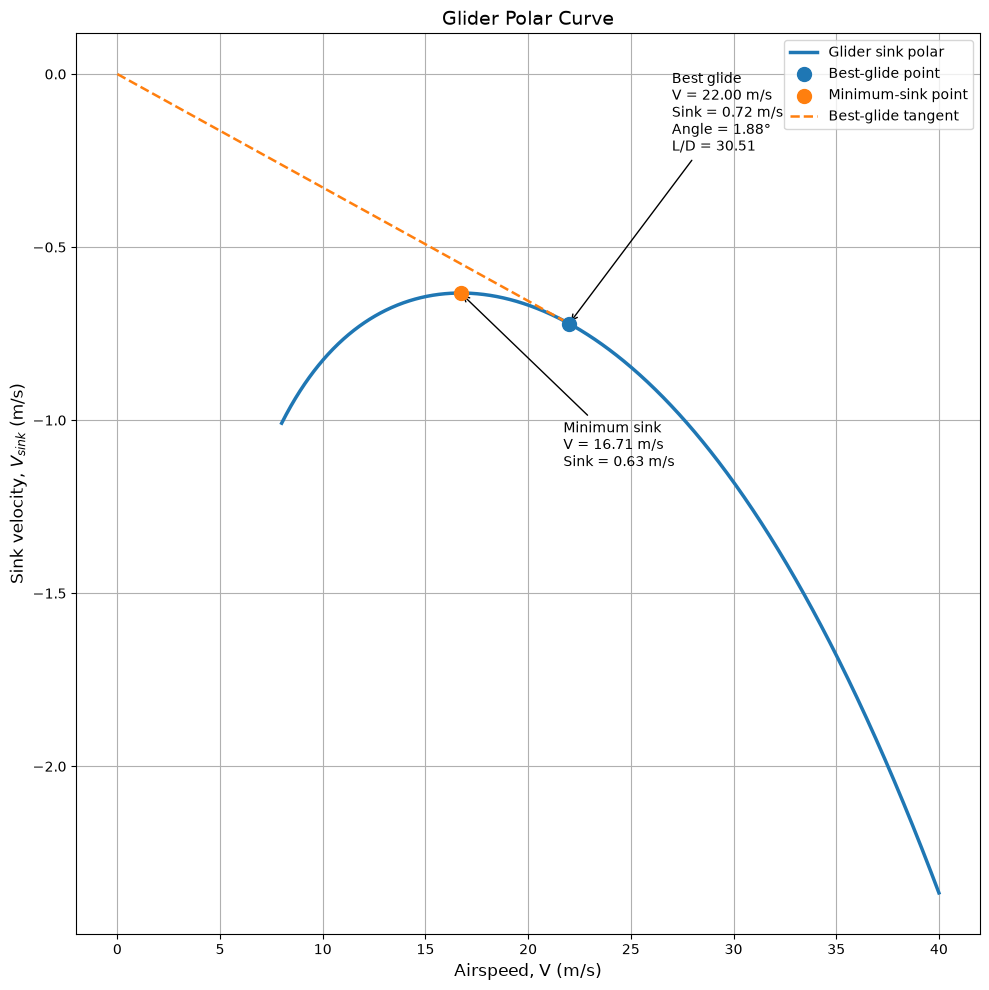

In [122]:
import numpy as np
import matplotlib.pyplot as plt
import math


# ============================================================
#                    USER INPUTS
# ============================================================

rho = 1.225          # Air density, kg/m^3
S = S_opt            # Wing reference area, m^2
AR = AR_opt          # Wing aspect ratio
e = Oswald_efficiency_factor(AR_opt)            # Oswald efficiency factor


# Airspeed range for plotting
V_min = 8.0          # Minimum plotted velocity, m/s
V_max = 40.0        # Maximum plotted velocity, m/s
number_of_points = 1000


# ============================================================
#                    BASIC CALCULATIONS
# ============================================================

# Sink-polar coefficients
A = (rho * S * CD0) / (2 * W)

B = (2 * W) / (np.pi * AR * e * rho * S)


# ============================================================
#              ANALYTICAL OPTIMUM VELOCITIES
# ============================================================

# Best-glide velocity:
# Maximum L/D or minimum glide angle
V_best_glide = (B / A) ** 0.25

# Sink rate at best-glide velocity
Vsink_best_glide = (
    A * V_best_glide**3
    + B / V_best_glide
)

# Minimum-sink velocity
V_min_sink = (B / (3 * A)) ** 0.25

# Minimum sink rate
Vsink_minimum = (
    A * V_min_sink**3
    + B / V_min_sink
)


# ============================================================
#                GLIDE ANGLE AND GLIDE RATIO
# ============================================================

# Exact glide angle based on the velocity components
glide_angle_rad = np.arctan(
    Vsink_best_glide / V_best_glide
)

glide_angle_deg = np.degrees(glide_angle_rad)

# Horizontal distance travelled per unit altitude lost
glide_ratio = V_best_glide / Vsink_best_glide

# Theoretical maximum L/D from drag polar
K = 1 / (np.pi * AR * e)

LD_max_theoretical = 1 / (
    2 * np.sqrt(CD0 * K)
)


# ============================================================
#               GENERATE GLIDER POLAR CURVE
# ============================================================

V = np.linspace(V_min, V_max, number_of_points)

Vsink = A * V**3 + B / V

# Glide angle at every velocity
glide_angle = np.degrees(np.arctan(Vsink / V))

# Glide ratio at every velocity
glide_ratio_curve = V / Vsink


# ============================================================
#                    DISPLAY RESULTS
# ============================================================

print("\n" + "=" * 60)
print("                 GLIDER POLAR RESULTS")
print("=" * 60)

# print(f"Aircraft mass                 = {mass:.3f} kg")
# print(f"Aircraft weight               = {W:.3f} N")
# print(f"Wing area                     = {S:.3f} m²")
# print(f"Aspect ratio                  = {AR:.3f}")
# print(f"Oswald efficiency factor      = {e:.3f}")
# print(f"Zero-lift drag coefficient    = {CD0:.5f}")

# print("\nSink-polar coefficients")
# print(f"A coefficient                 = {A:.8e}")
# print(f"B coefficient                 = {B:.8e}")

print("\nBest-glide condition")
print(f"Best-glide velocity           = {V_best_glide:.3f} m/s")
print(f"Sink rate at best glide       = {Vsink_best_glide:.3f} m/s")
print(f"Best glide angle              = {glide_angle_deg:.3f} degrees")
print(f"Maximum glide ratio           = {glide_ratio:.3f}:1")
print(f"Theoretical maximum L/D       = {LD_max_theoretical:.3f}")

print("\nMinimum-sink condition")
print(f"Minimum-sink velocity         = {V_min_sink:.3f} m/s")
print(f"Minimum sink rate             = {Vsink_minimum:.3f} m/s")

print("=" * 60)


# ============================================================
#                   GLIDER POLAR PLOT
# ============================================================

plt.figure(figsize=(10, 10))

plt.plot(
    V,
    -Vsink,
    linewidth=2.5,
    label="Glider sink polar"
)

# Best-glide point
plt.scatter(
    V_best_glide,
    -Vsink_best_glide,
    s=100,
    zorder=5,
    label="Best-glide point"
)

# Minimum-sink point
plt.scatter(
    V_min_sink,
    -Vsink_minimum,
    s=100,
    zorder=5,
    label="Minimum-sink point"
)

# Best-glide tangent line from origin
V_tangent = np.linspace(0, V_best_glide, 100)

tangent_slope = Vsink_best_glide / V_best_glide

Vsink_tangent = tangent_slope * V_tangent

plt.plot(
    V_tangent,
    -Vsink_tangent,
    linestyle="--",
    linewidth=1.8,
    label="Best-glide tangent"
)

# Best-glide annotation
plt.annotate(
    f"Best glide\n"
    f"V = {V_best_glide:.2f} m/s\n"
    f"Sink = {Vsink_best_glide:.2f} m/s\n"
    f"Angle = {glide_angle_deg:.2f}°\n"
    f"L/D = {glide_ratio:.2f}",
    xy=(V_best_glide, -Vsink_best_glide),
    xytext=(V_best_glide + 5, -Vsink_best_glide + 0.5),
    arrowprops=dict(arrowstyle="->"),
    fontsize=10
)

# Minimum-sink annotation
plt.annotate(
    f"Minimum sink\n"
    f"V = {V_min_sink:.2f} m/s\n"
    f"Sink = {Vsink_minimum:.2f} m/s",
    xy=(V_min_sink, -Vsink_minimum),
    xytext=(V_min_sink + 5, -Vsink_minimum - 0.5),
    arrowprops=dict(arrowstyle="->"),
    fontsize=10
)

plt.xlabel("Airspeed, V (m/s)", fontsize=12)
plt.ylabel("Sink velocity, $V_{sink}$ (m/s)", fontsize=12)
plt.title("Glider Polar Curve", fontsize=14)

plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()





             DRAG POLAR RESULTS
Zero-lift drag coefficient, CD0  = 0.01350
Aspect ratio, AR                 = 20.000
Oswald efficiency factor, e      = 0.8000
Induced-drag factor, k           = 0.01989

------------ MAXIMUM CL/CD -------------------
CL at maximum CL/CD              = 0.8244
CD at maximum CL/CD              = 0.02702
Maximum CL/CD                    = 30.51
Corresponding glide angle        = 1.877 deg


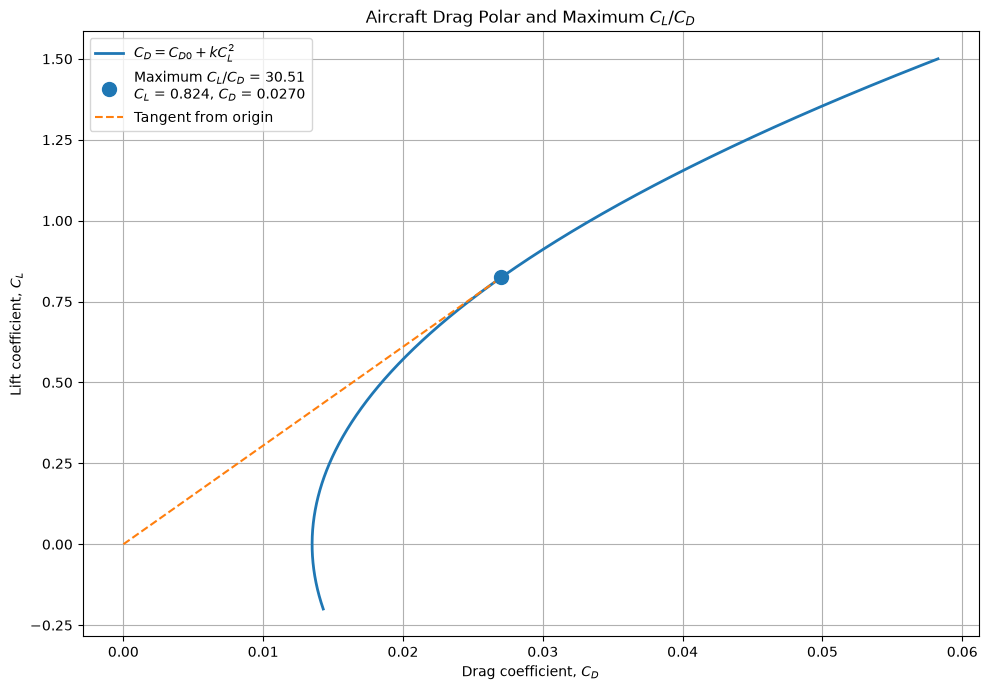

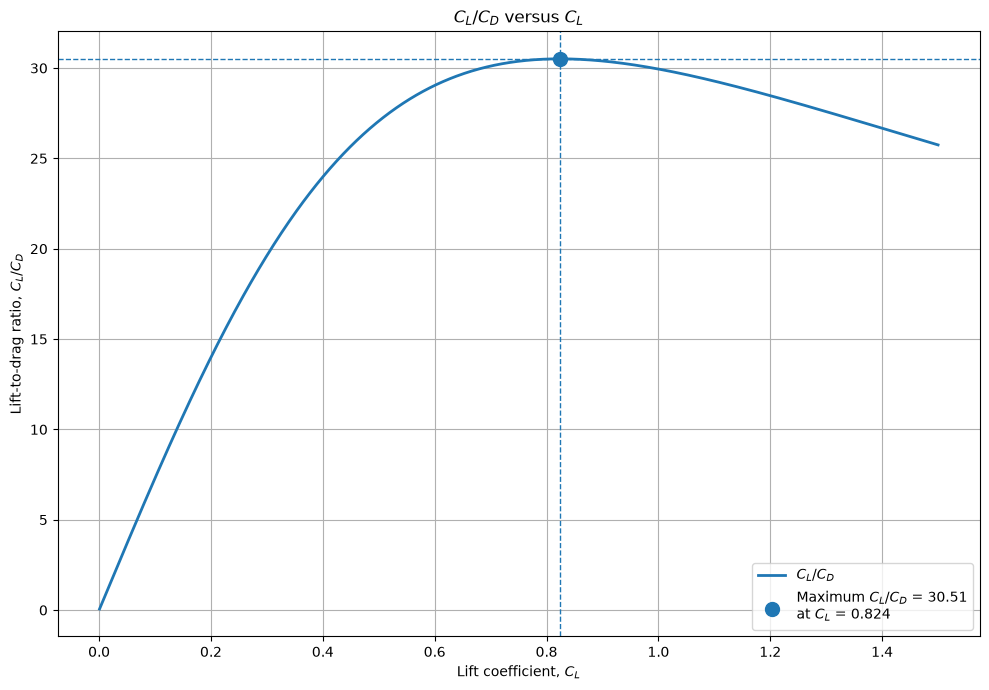

In [123]:
# ============================================================
# AIRCRAFT DRAG POLAR


import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# INPUTS
# ============================================================

CL_min = -0.2        # Minimum lift coefficient for plot
CL_max = 1.5         # Maximum lift coefficient for plot
number_of_points = 1000

# ============================================================
# INDUCED-DRAG FACTOR
# ============================================================

k = k_opt  # Induced-drag factor


# ============================================================
# CREATE CL RANGE
# ============================================================

CL = np.linspace(CL_min, CL_max, number_of_points)


# ============================================================
# DRAG POLAR
# ============================================================

CD = CD0 + k * CL**2


# ============================================================
# LIFT-TO-DRAG RATIO
# ============================================================

# Calculate CL/CD only for positive CL.
CL_CD = np.full_like(CL, np.nan)

positive_CL = CL > 0
CL_CD[positive_CL] = CL[positive_CL] / CD[positive_CL]


# ============================================================
# NUMERICAL MAXIMUM CL/CD
# ============================================================

maximum_index = np.nanargmax(CL_CD)

CL_at_maximum_CL_CD = CL[maximum_index]
CD_at_maximum_CL_CD = CD[maximum_index]
maximum_CL_CD = CL_CD[maximum_index]

glide_angle_rad = np.arctan(1.0 / maximum_CL_CD)
glide_angle_deg = np.degrees(glide_angle_rad)


# ============================================================
# DISPLAY RESULTS
# ============================================================

print("\n==============================================")
print("             DRAG POLAR RESULTS")
print("==============================================")

print(f"Zero-lift drag coefficient, CD0  = {CD0:.5f}")
print(f"Aspect ratio, AR                 = {AR:.3f}")
print(f"Oswald efficiency factor, e      = {e:.4f}")
print(f"Induced-drag factor, k           = {k:.5f}")

print("\n------------ MAXIMUM CL/CD -------------------")

print(
    f"CL at maximum CL/CD              = "
    f"{CL_at_maximum_CL_CD:.4f}"
)

print(
    f"CD at maximum CL/CD              = "
    f"{CD_at_maximum_CL_CD:.5f}"
)

print(
    f"Maximum CL/CD                    = "
    f"{maximum_CL_CD:.2f}"
)

print(
    f"Corresponding glide angle        = "
    f"{glide_angle_deg:.3f} deg"
)



# ============================================================
# PLOT 1: DRAG POLAR — CD VERSUS CL
# ============================================================

plt.figure(figsize=(10, 7))

plt.plot(
    CD,
    CL,
    linewidth=2,
    label=r"$C_D=C_{D0}+kC_L^2$"
)

plt.scatter(
    CD_at_maximum_CL_CD,
    CL_at_maximum_CL_CD,
    s=100,
    zorder=5,
    label=(
        f"Maximum $C_L/C_D$ = {maximum_CL_CD:.2f}\n"
        f"$C_L$ = {CL_at_maximum_CL_CD:.3f}, "
        f"$C_D$ = {CD_at_maximum_CL_CD:.4f}"
    )
)

# Line from origin tangent to drag polar.
tangent_CD = np.linspace(
    0,
    CD_at_maximum_CL_CD,
    100
)

tangent_CL = maximum_CL_CD * tangent_CD

plt.plot(
    tangent_CD,
    tangent_CL,
    linestyle="--",
    linewidth=1.5,
    label="Tangent from origin"
)

plt.xlabel(r"Drag coefficient, $C_D$")
plt.ylabel(r"Lift coefficient, $C_L$")
plt.title(r"Aircraft Drag Polar and Maximum $C_L/C_D$")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


# ============================================================
# PLOT 2: CL/CD VERSUS CL
# ============================================================

plt.figure(figsize=(10, 7))

plt.plot(
    CL,
    CL_CD,
    linewidth=2,
    label=r"$C_L/C_D$"
)

plt.scatter(
    CL_at_maximum_CL_CD,
    maximum_CL_CD,
    s=100,
    zorder=5,
    label=(
        f"Maximum $C_L/C_D$ = {maximum_CL_CD:.2f}\n"
        f"at $C_L$ = {CL_at_maximum_CL_CD:.3f}"
    )
)

plt.axvline(
    CL_at_maximum_CL_CD,
    linestyle="--",
    linewidth=1
)

plt.axhline(
    maximum_CL_CD,
    linestyle="--",
    linewidth=1
)

plt.xlabel(r"Lift coefficient, $C_L$")
plt.ylabel(r"Lift-to-drag ratio, $C_L/C_D$")
plt.title(r"$C_L/C_D$ versus $C_L$")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [124]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [125]:

def read_xflr5_polar(file_path):
    data = []
    airfoil_name = Path(file_path).stem

    with open(file_path, "r", errors="ignore") as f:
        for line in f:

            if "Calculated polar for:" in line:
                airfoil_name = line.split("Calculated polar for:", 1)[1].strip()

            parts = line.split()

            try:
                nums = [float(x) for x in parts]
            except ValueError:
                continue

            # XFLR5 airfoil polar columns:
            # alpha, CL, CD, CDp, Cm, ...
            if len(nums) >= 5:
                data.append(nums[:5])

    if len(data) == 0:
        raise ValueError("No valid XFLR5 polar data found.")

    data = np.asarray(data, dtype=float)

    alpha = data[:, 0]
    Cl = data[:, 1]
    Cd = data[:, 2]
    Cm = data[:, 4]

    valid = (
        np.isfinite(alpha)
        & np.isfinite(Cl)
        & np.isfinite(Cd)
        & np.isfinite(Cm)
        & (Cd > 0)
    )

    alpha = alpha[valid]
    Cl = Cl[valid]
    Cd = Cd[valid]
    Cm = Cm[valid]

    if len(alpha) < 5:
        raise ValueError("Not enough valid polar points.")

    # Sort by angle of attack
    sort_idx = np.argsort(alpha)

    alpha = alpha[sort_idx]
    Cl = Cl[sort_idx]
    Cd = Cd[sort_idx]
    Cm = Cm[sort_idx]

    # Remove duplicate alpha values if present
    alpha_unique, unique_idx = np.unique(alpha, return_index=True)

    alpha = alpha_unique
    Cl = Cl[unique_idx]
    Cd = Cd[unique_idx]
    Cm = Cm[unique_idx]

    return airfoil_name, alpha, Cl, Cd, Cm


def find_linear_region(alpha, Cl):
    n_points = len(alpha)

    if n_points < 5:
        raise ValueError("At least 5 polar points are required.")

    # Use 20% of data, limited to available points
    window_size = max(5, round(0.20 * n_points))
    window_size = min(window_size, n_points)

    best_score = -np.inf
    best_R2 = None
    best_idx = None
    best_p = None

    for i in range(n_points - window_size + 1):
        idx = np.arange(i, i + window_size)

        p = np.polyfit(alpha[idx], Cl[idx], 1)

        slope = p[0]

        if slope <= 0:
            continue

        Cl_fit = np.polyval(p, alpha[idx])

        SSres = np.sum((Cl[idx] - Cl_fit) ** 2)
        SStot = np.sum((Cl[idx] - np.mean(Cl[idx])) ** 2)

        if SStot <= 0:
            continue

        R2 = 1.0 - SSres / SStot

        # Prefer highly linear regions near alpha = 0 deg
        mean_alpha = np.mean(alpha[idx])
        score = R2 - 0.05 * abs(mean_alpha)

        if score > best_score:
            best_score = score
            best_R2 = R2
            best_idx = idx
            best_p = p

    if best_p is None:
        raise ValueError("Could not identify a valid positive-slope linear region.")

    return best_p, best_idx, best_R2


def interpolate_at_cl(alpha, Cl, Cd, Cm, Cl_target):
    """
    Interpolate alpha, Cd and Cm at a required 2D airfoil Cl.

    Only the pre-stall positive-lift branch is used.
    """

    # Find maximum Cl point as approximate positive stall point
    stall_idx = np.argmax(Cl)

    alpha_branch = alpha[:stall_idx + 1]
    Cl_branch = Cl[:stall_idx + 1]
    Cd_branch = Cd[:stall_idx + 1]
    Cm_branch = Cm[:stall_idx + 1]

    # Keep the useful approximately monotonic positive-slope branch
    dCl = np.gradient(Cl_branch, alpha_branch)
    valid_branch = dCl > 0

    alpha_branch = alpha_branch[valid_branch]
    Cl_branch = Cl_branch[valid_branch]
    Cd_branch = Cd_branch[valid_branch]
    Cm_branch = Cm_branch[valid_branch]

    if len(Cl_branch) < 2:
        raise ValueError("Could not construct a valid pre-stall Cl branch.")

    # Sort by Cl because np.interp requires increasing x values
    sort_idx = np.argsort(Cl_branch)

    Cl_branch = Cl_branch[sort_idx]
    alpha_branch = alpha_branch[sort_idx]
    Cd_branch = Cd_branch[sort_idx]
    Cm_branch = Cm_branch[sort_idx]

    # Remove duplicate Cl values
    Cl_unique, unique_idx = np.unique(Cl_branch, return_index=True)

    Cl_branch = Cl_unique
    alpha_branch = alpha_branch[unique_idx]
    Cd_branch = Cd_branch[unique_idx]
    Cm_branch = Cm_branch[unique_idx]

    if Cl_target < np.min(Cl_branch) or Cl_target > np.max(Cl_branch):
        raise ValueError(
            f"Required section Cl = {Cl_target:.4f} is outside the "
            f"usable pre-stall range "
            f"[{np.min(Cl_branch):.4f}, {np.max(Cl_branch):.4f}]."
        )

    alpha_target = np.interp(Cl_target, Cl_branch, alpha_branch)
    Cd_target = np.interp(Cl_target, Cl_branch, Cd_branch)
    Cm_target = np.interp(Cl_target, Cl_branch, Cm_branch)

    return alpha_target, Cd_target, Cm_target


def process_airfoil(file_path, CL_wing, AR, e):
    if AR <= 0:
        raise ValueError("Aspect ratio must be positive.")

    if not 0 < e <= 1:
        raise ValueError("Oswald efficiency factor e must be between 0 and 1.")

    name, alpha, Cl, Cd, Cm = read_xflr5_polar(file_path)

    best_p, best_idx, best_R2 = find_linear_region(alpha, Cl)

    # 2D airfoil lift-curve slope
    a0_deg = best_p[0]       # 1/deg
    intercept = best_p[1]

    if abs(a0_deg) < 1e-12:
        raise ValueError("Calculated airfoil lift slope is zero.")

    a0_rad = a0_deg * 180.0 / np.pi

    alpha_L0 = -intercept / a0_deg

    # Finite-wing lift-curve slope
    a_wing_deg = a0_deg / (
        1.0 + (57.2958 * a0_deg) / (np.pi * e * AR)
    )

    a_wing_rad = a_wing_deg * 180.0 / np.pi

    # Estimated 3D wing geometric angle of attack
    alpha_wing_req = alpha_L0 + CL_wing / a_wing_deg

    # Approximate section Cl
    # For a first estimate, use section cl approximately equal to wing CL.
    Cl_section_req = CL_wing

    # Obtain 2D airfoil operating point from the polar
    alpha_airfoil_req, Cd_req, Cm_req = interpolate_at_cl(
        alpha, Cl, Cd, Cm, Cl_section_req
    )

    ClCd_req = Cl_section_req / Cd_req

    # Induced drag coefficient
    CDi = CL_wing**2 / (np.pi * e * AR)

    # Simple wing drag estimate
    # Assumes airfoil Cd is representative of average wing profile drag.
    CD_wing = Cd_req + CDi

    # Approximate stall information
    stall_idx = np.argmax(Cl)

    return {
        "name": name,
        "file_path": file_path,

        "alpha": alpha,
        "Cl": Cl,
        "Cd": Cd,
        "Cm": Cm,

        "best_idx": best_idx,
        "best_p": best_p,
        "best_R2": best_R2,

        "a0_deg": a0_deg,
        "a0_rad": a0_rad,
        "alpha_L0": alpha_L0,

        "a_wing_deg": a_wing_deg,
        "a_wing_rad": a_wing_rad,

        "alpha_airfoil_req": alpha_airfoil_req,
        "alpha_wing_req": alpha_wing_req,

        "Cl_req": Cl_section_req,
        "Cd_req": Cd_req,
        "Cm_req": Cm_req,
        "ClCd_req": ClCd_req,

        "CDi": CDi,
        "CD_wing": CD_wing,

        "Cl_max": Cl[stall_idx],
        "alpha_stall": alpha[stall_idx],
    }

In [126]:
n_files = 1

CL_wing = CL_best_opt
AR = AR_opt

results = []


folder = r"C:\Users\Senura\Desktop\Aircraft design project\Xflr analysis\v 22"

filename = "FX 67 K 170.txt"    # Change only this line

file_path = f"{folder}\\{filename}"

try:
    result = process_airfoil(
        file_path=file_path,
        CL_wing=CL_wing,
        AR=AR,
        e=e
    )

    results.append(result)

    print(f"Processed: {result['name']}")

except Exception as err:
    print(f"Skipped file because: {err}")

if len(results) == 0:
    raise RuntimeError("No valid airfoil results were calculated.")



print("\n========== FINAL RESULTS ==========")
print(
    f"Wing CL = {CL_wing:.4f}, "
    f"AR = {AR:.2f}, "
    f"e = {e:.4f}"
)

for r in results:
    print("\n----------------------------------")
    print(f"Airfoil: {r['name']}")

    print(
        f"Linear region    = "
        f"{r['alpha'][r['best_idx'][0]]:.2f} to "
        f"{r['alpha'][r['best_idx'][-1]]:.2f} deg"
    )

    print(f"Linear-fit R²    = {r['best_R2']:.6f}")

    print(f"a0              = {r['a0_deg']:.5f} per deg")
    print(f"a0              = {r['a0_rad']:.3f} per rad")

    print(f"alpha_L=0       = {r['alpha_L0']:.3f} deg")

    print(f"Wing slope a    = {r['a_wing_deg']:.5f} per deg")
    print(f"Wing slope a    = {r['a_wing_rad']:.3f} per rad")

    print(
        f"Airfoil alpha    = "
        f"{r['alpha_airfoil_req']:.3f} deg"
    )

    print(
        f"Wing alpha est.  = "
        f"{r['alpha_wing_req']:.3f} deg"
    )
    print("----------------------------------")
    print(f"Section Cl       = {r['Cl_req']:.4f}")
    print(f"Airfoil Cd       = {r['Cd_req']:.5f}")
    print(f"Airfoil Cl/Cd    = {r['ClCd_req']:.2f}")
    print(f"Airfoil Cm       = {r['Cm_req']:.4f}")
    print("----------------------------------")
    print(f"Induced CD       = {r['CDi']:.5f}")
    print(f"Wing CD approx.  = {r['CD_wing']:.5f}")
    print("----------------------------------")
    print(f"Maximum Cl       = {r['Cl_max']:.4f}")
    print(f"Stall alpha      = {r['alpha_stall']:.3f} deg")

Processed: FX 67-K-170/17 AIRFOIL

========== FINAL RESULTS ==========
Wing CL = 0.8238, AR = 20.00, e = 0.8000

----------------------------------
Airfoil: FX 67-K-170/17 AIRFOIL
Linear region    = -2.40 to 2.40 deg
Linear-fit R²    = 0.999476
a0              = 0.11104 per deg
a0              = 6.362 per rad
alpha_L=0       = -4.968 deg
Wing slope a    = 0.09857 per deg
Wing slope a    = 5.648 per rad
Airfoil alpha    = 2.411 deg
Wing alpha est.  = 3.389 deg
----------------------------------
Section Cl       = 0.8238
Airfoil Cd       = 0.00692
Airfoil Cl/Cd    = 119.02
Airfoil Cm       = -0.1129
----------------------------------
Induced CD       = 0.01350
Wing CD approx.  = 0.02042
----------------------------------
Maximum Cl       = 1.3138
Stall alpha      = 13.900 deg


In [127]:
# ============================================================
# WING LIFT SLOPE, WING AoA, AND WING ZERO-LIFT AoA
# ============================================================

import numpy as np

# ---------------- INPUTS ----------------
a0 = r['a0_deg']           # Airfoil lift-curve slope, per degree
CL_required = CL_best_opt   # Required wing lift coefficient

alpha_airfoil = r['alpha_airfoil_req']  # Airfoil AoA that gives CL_required, degrees


# ---------------- CALCULATIONS ----------------


# Finite-wing lift-curve slope, per degree
a_wing = a0 / (
    1.0 + (a0 * 57.3) / (np.pi * e * AR)
)

# Airfoil zero-lift angle using:
# CL = a0(alpha_airfoil - alpha_L0)
alpha_L0_airfoil = alpha_airfoil - CL_required / a0

# Wing zero-lift angle
# For an untwisted wing with constant airfoil section:
alpha_L0_wing = alpha_L0_airfoil

# Wing AoA required to produce the same CL
alpha_wing = alpha_L0_wing + CL_required / a_wing

#airfoil zero-aoa  lift coefficient
CL0_airfoil = a0 * -alpha_L0_airfoil

#wing zero-aoa  lift coefficient
CL0_wing = a_wing * -alpha_L0_wing   


# ---------------- OUTPUTS ----------------

print(f"Airfoil lift slope, a0       = {a0:.5f} per deg")
print(f"Wing lift slope, a           = {a_wing:.5f} per deg")
print('----------------------------------')
print(f"Airfoil zero-lift AoA        = {alpha_L0_airfoil:.3f} deg")
print(f"Wing zero-lift AoA           = {alpha_L0_wing:.3f} deg")
print('----------------------------------')
print(f"Airfoil zero-aoa  CL         = {CL0_airfoil:.4f}")
print(f"Wing zero-aoa  CL            = {CL0_wing:.4f}")
print('----------------------------------')
print(f"Airfoil AoA for CL={CL_required:.4f} = {alpha_airfoil:.3f} deg")
print(f"Wing AoA for CL={CL_required:.4f}    = {alpha_wing:.3f} deg")

Airfoil lift slope, a0       = 0.11104 per deg
Wing lift slope, a           = 0.09857 per deg
----------------------------------
Airfoil zero-lift AoA        = -5.007 deg
Wing zero-lift AoA           = -5.007 deg
----------------------------------
Airfoil zero-aoa  CL         = 0.5560
Wing zero-aoa  CL            = 0.4936
----------------------------------
Airfoil AoA for CL=0.8238 = 2.411 deg
Wing AoA for CL=0.8238    = 3.350 deg


In [128]:
# Wing geometry and Reynolds number calculator

# Fixed design inputs

V = V_bg_opt                # Flight speed, m/s
nu = 1.5111e-5           # Kinematic viscosity, m^2/s

# User input
lambda_ratio = 0.8    #float(input("Enter taper ratio lambda = ct/cr: "))

# Validation
if lambda_ratio <= 0 or lambda_ratio > 1:
    raise ValueError("Taper ratio must be between 0 and 1.")


# Root and tip chords
cr = 2 * S_opt / (b * (1 + lambda_ratio))
ct = lambda_ratio * cr

# Reynolds numbers
Re_root = V * cr / nu
Re_tip = V * ct / nu

# Mean aerodynamic chord
MAC = (2 / 3) * cr * ((1 + lambda_ratio + lambda_ratio**2) / (1 + lambda_ratio))
Re_MAC = V * MAC / nu

# Output
print("\n----- RESULTS -----")
print(f"Wing area, S          = {S_opt:.4f} m^2")
print(f"Taper ratio, lambda   = {lambda_ratio:.4f}")
print(f"Root chord, cr        = {cr:.4f} m")
print(f"Tip chord, ct         = {ct:.4f} m")
print(f"Mean aerodynamic chord= {MAC:.4f} m")
print(f"Root Reynolds number  = {Re_root:.4e}")
print(f"Tip Reynolds number   = {Re_tip:.4e}")
print(f"MAC Reynolds number   = {Re_MAC:.4e}")


----- RESULTS -----
Wing area, S          = 11.2500 m^2
Taper ratio, lambda   = 0.8000
Root chord, cr        = 0.8333 m
Tip chord, ct         = 0.6667 m
Mean aerodynamic chord= 0.7531 m
Root Reynolds number  = 1.2131e+06
Tip Reynolds number   = 9.7051e+05
MAC Reynolds number   = 1.0963e+06


In [129]:
import numpy as np
import matplotlib.pyplot as plt


# ====================== INPUTS ======================

N = 19                   # Number of segments - 1
S = S_opt               # Wing area, m^2
AR = AR_opt                # Aspect ratio

alpha_twist = 0.0       # Twist angle, deg
i_w =  alpha_wing       # Wing setting angle, deg
a_2d = a0 * 57.3           # 2D lift-curve slope, 1/rad
alpha_0 = alpha_L0_airfoil        # Zero-lift angle of attack, deg

rho = 1.225             # Air density, kg/m^3
V = V_bg_opt                  # Airspeed, m/s
g = 9.81                # Gravitational acceleration, m/s^2

# ====================== WING GEOMETRY ======================

b = np.sqrt(AR * S)     # Wing span, m
MC = S / b             # Mean chord used in the original MATLAB code, m

Croot = (
    1.5 * (1 + lambda_ratio) * MC
    / (1 + lambda_ratio + lambda_ratio**2)
)                       # Root chord, m

# MATLAB:
# theta = pi/(2*N):pi/(2*N):pi/2
theta = np.arange(1, N + 1) * np.pi / (2 * N)

# MATLAB:
# alpha = i_w + alpha_twist : -alpha_twist/(N-1) : i_w
alpha = np.linspace(i_w + alpha_twist, i_w, N)

# Semi-span locations
z = (b / 2) * np.cos(theta)

# Local chord at each segment
c = Croot * (
    1 - (1 - lambda_ratio) * np.cos(theta)
)

# Lifting-line parameter
mu = c * a_2d / (4 * b)

# Left-hand side of lifting-line equations
LHS = mu * (alpha - alpha_0) / 57.3

# ====================== SOLVE FOR FOURIER COEFFICIENTS ======================

B = np.zeros((N, N))

for i in range(N):
    for j in range(N):
        harmonic = 2 * (j + 1) - 1

        B[i, j] = (
            np.sin(harmonic * theta[i])
            * (
                1
                + (
                    mu[i] * harmonic
                    / np.sin(theta[i])
                )
            )
        )

# Equivalent to MATLAB: A = B \ transpose(LHS)
A = np.linalg.solve(B, LHS)

# ====================== LIFT DISTRIBUTION ======================

sum1 = np.zeros(N)
sum2 = np.zeros(N)

for i in range(N):
    for j in range(N):
        harmonic = 2 * (j + 1) - 1

        sum1[i] += (
            harmonic
            * A[j]
            * np.sin(harmonic * theta[i])
        )

        sum2[i] += (
            A[j]
            * np.sin(harmonic * theta[i])
        )

# Local section lift coefficient
CL = 4 * b * sum2 / c

# Add zero lift coefficient at the wing tip
CL1 = np.concatenate(([0.0], CL))

# Add the wing-tip location to the semi-span coordinates
y_s = np.concatenate(([b / 2], z))

# ====================== WING LIFT ======================

CL_wing = np.pi * AR * A[0]

Lift = 0.5 * rho * V**2 * S * CL_wing

weight = Lift / g

# ====================== OUTPUTS ======================

print(f"Wing span, b                = {b:.6f} m")
print(f"Mean chord, MC              = {MC:.6f} m")
print(f"MAC, Mean Aerodynamic Chord = {MAC:.6f} m")
print('--------------------------------------------')
print(f"Actual Wing lift coefficient= {CL_wing:.6f}")
print(f"Lift at {V:.2f} m/s         = {Lift:.6f} N")
print(f"Equivalent supported mass   = {weight:.6f} kg")

Wing span, b                = 15.000000 m
Mean chord, MC              = 0.750000 m
MAC, Mean Aerodynamic Chord = 0.753086 m
--------------------------------------------
Actual Wing lift coefficient= 0.821665
Lift at 22.00 m/s         = 2739.806086 N
Equivalent supported mass   = 279.287063 kg


In [130]:
import math

print("=" * 50)
print(" OPTIMUM HORIZONTAL TAIL SIZING")
print("=" * 50)

# -----------------------------
# Inputs
# -----------------------------
c = MAC # Mean aerodynamic chord, m
Sw = S_opt  # Wing area, m^2
VH = 0.6   # Horizontal tail volume coefficient
Kc = 1.0   # Correction factor for tail efficiency
b_w = b  # Wing span, m
L = 0.45*b_w  # Aircraft length, m
l_over_L = 0.65  # Tail arm to aircraft length ratio

# -----------------------------
# Calculations
# -----------------------------

# Optimum tail arm

l= l_over_L * L
Df = (4 * c * Sw * VH) / (math.pi * l**2)

# Horizontal tail area
Sh = (c * Sw * VH) / l

# -----------------------------
# Results
# -----------------------------
print("\n" + "=" * 50)
print("RESULTS")
print("=" * 50)

print(f"Optimum Tail Arm (l)      = {l:.3f} m")
print(f"Horizontal Tail Area (Sh) = {Sh:.3f} m²")
print(f"Maximum fuselage diameter (Df) = {Df:.3f} m")
print(f"Aircraft length (L) = {L:.3f} m")

print("=" * 50)




 OPTIMUM HORIZONTAL TAIL SIZING

RESULTS
Optimum Tail Arm (l)      = 4.388 m
Horizontal Tail Area (Sh) = 1.159 m²
Maximum fuselage diameter (Df) = 0.336 m
Aircraft length (L) = 6.750 m


In [131]:
# ============================================================
#  WING 
# ============================================================

AR_w = AR_opt # wing aspect ratio, AR_w

CL_w = CL_best_opt # wing lift coefficient

CL0_w = CL0_wing # wing zero-aoa lift coefficient, CL0_w

alpha_w = alpha_wing # wing angle of attack, alpha_w (deg)

CLalpha_w = a_wing  # wing lift-curve slope, 1/deg  5.5341

sweep_deg = 0.0 # wing sweep angle, Lambda (deg)    

Cm_af = -0.14  # airfoil pitching-moment coefficient

alpha_twist_deg = 0 # wing twist angle, alpha_t (deg)

alpha_f = 1.87 # fuselage angle of attack, alpha_f (deg) glide angle

i_w = alpha_w - alpha_f # wing incidence angle, i_w (deg)

# ============================================================
#  TAIL INITIAL INPUTS
# ============================================================

eta_h = 0.85 # tail efficiency, eta_h

AR_h = 4.0 # tail aspect ratio, AR_h 

# ============================================================

# ============================================================
# CG AND AERODYNAMIC-CENTRE INPUTS
# ============================================================

h = 0.45 # nondimensional CG position, h

h0 = 0.25 # nondimensional aerodynamic-centre position, h0


In [132]:
import math


# ============================================================
#  WING-FUSELAGE PITCHING MOMENT
# ============================================================

cos_sweep = math.cos(sweep_deg)

Cm0_wf = (Cm_af * (AR_w * cos_sweep**2 / (AR_w + 2.0 * cos_sweep))+ 0.01 * alpha_twist_deg )

# ============================================================
# REQUIRED TAIL LIFT COEFFICIENT FROM TRIM
# ============================================================

CL_h = (Cm0_wf + CL_w * (h - h0)) / (eta_h * VH)

print(f"Required tail lift coefficient from trim: {CL_h:.4f}")

Required tail lift coefficient from trim: 0.0735


In [133]:

CL_wing = CL_h
AR = AR_h

results = []


folder = r"C:\Users\Senura\Desktop\Aircraft design project\Xflr analysis\tail\tail airfoils"

filename = "NACA 0012_T1_Re0.743_M0.06_N9.0.txt"    # Change only this line

file_path = f"{folder}\\{filename}"

try:
    result = process_airfoil(
        file_path=file_path,
        CL_wing=CL_wing,
        AR=AR,
        e=e
    )

    results.append(result)

    print(f"Processed: {result['name']}")

except Exception as err:
    print(f"Skipped file because: {err}")

if len(results) == 0:
    raise RuntimeError("No valid airfoil results were calculated.")


print("\n========== FINAL RESULTS ==========")
print(
    f"Wing CL = {CL_wing:.4f}, "
    f"AR = {AR:.2f}, "
    f"e = {e:.4f}"
)

for r in results:
    print("\n----------------------------------")
    print(f"Airfoil: {r['name']}")

    print(
        f"Linear region    = "
        f"{r['alpha'][r['best_idx'][0]]:.2f} to "
        f"{r['alpha'][r['best_idx'][-1]]:.2f} deg"
    )

    print(f"Linear-fit R²    = {r['best_R2']:.6f}")

    print(f"a0              = {r['a0_deg']:.5f} per deg")
    print(f"a0              = {r['a0_rad']:.3f} per rad")

    print(f"alpha_L=0       = {r['alpha_L0']:.3f} deg")

    print(f"Wing slope a    = {r['a_wing_deg']:.5f} per deg")
    print(f"Wing slope a    = {r['a_wing_rad']:.3f} per rad")

    print(
        f"Airfoil alpha    = "
        f"{r['alpha_airfoil_req']:.3f} deg"
    )

    print(
        f"Wing alpha est.  = "
        f"{r['alpha_wing_req']:.3f} deg"
    )
    print("----------------------------------")
    print(f"Section Cl       = {r['Cl_req']:.4f}")
    print(f"Airfoil Cd       = {r['Cd_req']:.5f}")
    print(f"Airfoil Cl/Cd    = {r['ClCd_req']:.2f}")
    print(f"Airfoil Cm       = {r['Cm_req']:.4f}")
    print("----------------------------------")
    print(f"Induced CD       = {r['CDi']:.5f}")
    print(f"Wing CD approx.  = {r['CD_wing']:.5f}")
    print("----------------------------------")
    print(f"Maximum Cl       = {r['Cl_max']:.4f}")
    print(f"Stall alpha      = {r['alpha_stall']:.3f} deg")

Processed: NACA 0012

========== FINAL RESULTS ==========
Wing CL = 0.0735, AR = 4.00, e = 0.8000

----------------------------------
Airfoil: NACA 0012
Linear region    = -2.20 to 2.20 deg
Linear-fit R²    = 0.999999
a0              = 0.10581 per deg
a0              = 6.063 per rad
alpha_L=0       = 0.000 deg
Wing slope a    = 0.06601 per deg
Wing slope a    = 3.782 per rad
Airfoil alpha    = 0.694 deg
Wing alpha est.  = 1.113 deg
----------------------------------
Section Cl       = 0.0735
Airfoil Cd       = 0.00567
Airfoil Cl/Cd    = 12.96
Airfoil Cm       = 0.0014
----------------------------------
Induced CD       = 0.00054
Wing CD approx.  = 0.00621
----------------------------------
Maximum Cl       = 1.2973
Stall alpha      = 14.800 deg


In [134]:
# ============================================================
# Tail LIFT SLOPE, TAIL AoA, AND TAIL ZERO-LIFT AoA
# ============================================================

import numpy as np

# ---------------- INPUTS ----------------
a0_h = r['a0_deg']           # Airfoil lift-curve slope, per degree

alpha_h_airfoil = r['alpha_airfoil_req']  # Airfoil AoA that gives CL_required, degrees


# ---------------- CALCULATIONS ----------------


# Finite-wing lift-curve slope, per degree
a_h_tail = a0_h / (
    1.0 + (a0_h * 57.3) / (np.pi * e * AR)
)

# Airfoil zero-lift angle using:
# CL = a0(alpha_airfoil - alpha_L0)
alpha_h_L0_airfoil = alpha_h_airfoil - CL_h / a0_h

# Wing zero-lift angle
# For an untwisted wing with constant airfoil section:
alpha_h_L0_wing = alpha_h_L0_airfoil

# Wing AoA required to produce the same CL
alpha_wing = alpha_h_L0_wing + CL_h / a_h_tail

#airfoil zero-aoa  lift coefficient
CL0_airfoil_tail = a0_h * -alpha_h_L0_airfoil

#tail zero-aoa  lift coefficient
CL0_tail = a_h_tail * -alpha_h_L0_wing   


# ---------------- OUTPUTS ----------------

print(f"Airfoil lift slope, a0_h      = {a0_h:.5f} per deg")
print(f"Tail lift slope, a_h_tail     = {a_h_tail:.5f} per deg")
print('----------------------------------')
print(f"Airfoil zero-lift AoA         = {alpha_h_L0_airfoil:.3f} deg")
print(f"Tail zero-lift AoA            = {alpha_h_L0_wing:.3f} deg")
print('----------------------------------')
print(f"Airfoil zero-aoa  CL          = {CL0_airfoil_tail:.4f}")
print(f"Tail zero-aoa  CL             = {CL0_tail:.4f}")
print('----------------------------------')
print(f"Airfoil AoA for CL={CL_h:.4f}   = {alpha_h_airfoil:.3f} deg")
print(f"Tail AoA for CL={CL_h:.4f}      = {alpha_wing:.3f} deg")

Airfoil lift slope, a0_h      = 0.10581 per deg
Tail lift slope, a_h_tail     = 0.06600 per deg
----------------------------------
Airfoil zero-lift AoA         = -0.001 deg
Tail zero-lift AoA            = -0.001 deg
----------------------------------
Airfoil zero-aoa  CL          = 0.0001
Tail zero-aoa  CL             = 0.0001
----------------------------------
Airfoil AoA for CL=0.0735   = 0.694 deg
Tail AoA for CL=0.0735      = 1.113 deg


In [135]:
# TAIL 
# ============================================================


Clalpha_h = r['a0_deg']   # tail AIRFOIL lift-curve slope, Clalpha_h (1/deg)

alpha_L0_h_deg = 0.0 # tail zero-lift angle


In [136]:
# TAil calculations
# ============================================================
#  FINITE-WING HORIZONTAL-TAIL LIFT-CURVE SLOPE AND REQUIRED TAIL ANGLE OF ATTACK
# ============================================================

CLalpha_h = ( Clalpha_h / (1.0+ (Clalpha_h / (math.pi * AR_h*e))))

alpha_h = ( CL_h / CLalpha_h )

# ============================================================
# DOWNWASH
# ============================================================

epsilon_0 = ((2.0 * CL0_w) / (math.pi * AR_opt))*(180/math.pi)  # Downwash at zero AoA, epsilon_0 (deg)

downwash_slope = ( 2.0 * CLalpha_w * 57.3 / (math.pi * AR_opt))  # Downwash slope, dε/dalpha (1/deg)

epsilon =  epsilon_0 + (downwash_slope * alpha_w)



# print(f"downwash_slope = {downwash_slope: .4f}")
# print(f"epsilon_0_deg = {epsilon_0_deg: .4f} deg")
# print(f"epsilon_deg = {epsilon_deg: .4f} deg")
# print(f"epsilon_rad = {epsilon_rad: .4f} rad")
# print(f"epsilon_0_rad = {epsilon_0_rad: .4f} rad")
# print(f"alpha_w_rad = {alpha_w_rad: .4f} rad")

# ============================================================
# REQUIRED TAIL ANGLE AND INCIDENCE FOR TRIM
# ============================================================

i_h = ( alpha_h - alpha_f + epsilon)


# ============================================================
# RESULTS
# ============================================================

print("\n" + "=" * 72)
print(" CALCULATION RESULTS")
print("=" * 72)



print("\n1. Wing–fuselage pitching moment")
print("-" * 72)
print(f"Cm0,wf                         = {Cm0_wf: .5f}")
print(f"Wing incidence, i_w            = {i_w: .4f} deg")

print("\n2. Downwash")
print("-" * 72)
print(f"Downwash at zero AoA, epsilon_0 = {epsilon_0: .4f} deg")
print(f"Downwash slope, dε/dalpha       = {downwash_slope: .4f}")
print(f"Total downwash angle, epsilon   = {epsilon: .4f} deg")

print("\n3. Horizontal-tail aerodynamic parameters")
print("-" * 72)
print(f"tail CL_h                       = {CL_h: .5f}")
print(f"Tail airfoil slope, Clalpha_h   = {Clalpha_h: .4f} 1/rad")
print(f"Finite-tail slope, CLalpha_h    = {CLalpha_h: .4f} 1/rad")
print(f"Tail angle of attack, alpha_h   = {alpha_h: .4f} deg")
print(f"tail incidence, i_h             = {i_h: .4f} deg")


print("\n5. Tail setting required for exact trim")
print("-" * 72)
print(f"tail incidence, i_h    = {i_h: .4f} deg")

print("\n" + "=" * 72)



 CALCULATION RESULTS

1. Wing–fuselage pitching moment
------------------------------------------------------------------------
Cm0,wf                         = -0.12727
Wing incidence, i_w            =  1.4799 deg

2. Downwash
------------------------------------------------------------------------
Downwash at zero AoA, epsilon_0 =  0.9002 deg
Downwash slope, dε/dalpha       =  0.1798
Total downwash angle, epsilon   =  1.5024 deg

3. Horizontal-tail aerodynamic parameters
------------------------------------------------------------------------
tail CL_h                       =  0.07349
Tail airfoil slope, Clalpha_h   =  0.1058 1/rad
Finite-tail slope, CLalpha_h    =  0.1047 1/rad
Tail angle of attack, alpha_h   =  0.7018 deg
tail incidence, i_h             =  0.3343 deg

5. Tail setting required for exact trim
------------------------------------------------------------------------
tail incidence, i_h    =  0.3343 deg



In [137]:
#Neutral point calculation

hn = 0.25 + (eta_h * VH * (CLalpha_h / CLalpha_w) * (1 - downwash_slope))

print(f"Neutral point location, hn = {hn:.4f} (nondimensional)")
print(f"Static margin, SM = {hn - h:.4f} (nondimensional)")

Neutral point location, hn = 0.6944 (nondimensional)
Static margin, SM = 0.2444 (nondimensional)


Trim angle of attack: 3.41 deg
Wing AoA: 3.35 deg


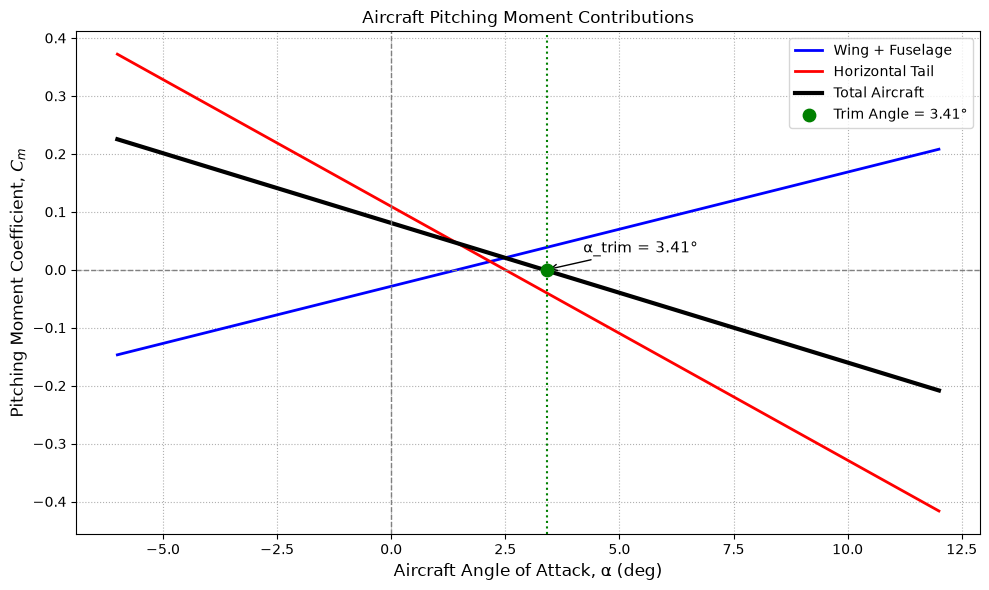

In [138]:
# Cm plotting

import numpy as np
import matplotlib.pyplot as plt

alpha = np.linspace(-6, 12, 200)

CL0_w_the = CL_best_opt - CLalpha_w * alpha_w

#----------------------------------------------------------------------------------------------------------------------------

Cm_wing = Cm0_wf + (CL0_w_the + CLalpha_w * alpha) * (h-h0)  # Aircraft wing-fuselage pitching moment coefficient

Cm_tail = -1*eta_h * VH * CLalpha_h * (alpha*(1-downwash_slope) - epsilon_0 - i_w + i_h)  # Aircraft horizontal tail pitching moment coefficient

Cm_aircraft = Cm_wing + Cm_tail # Aircraft total pitching moment coefficient

#----------------------------------------------------------------------------------------------------------------------------

# Find where Cm changes sign
idx = np.where(np.diff(np.sign(Cm_aircraft)))[0]

if len(idx) > 0:
    i = idx[0]

    alpha_trim = np.interp(
        0,
        [Cm_aircraft[i], Cm_aircraft[i+1]],
        [alpha[i], alpha[i+1]]
    )
else:
    alpha_trim = None

print(f"Trim angle of attack: {alpha_trim:.2f} deg" if alpha_trim is not None else "No trim angle found.")
print(f"Wing AoA: {alpha_w:.2f} deg")

plt.figure(figsize=(10,6))

# Wing-Fuselage
plt.plot(alpha,
         Cm_wing,
         color='blue',
         linewidth=2,
         label='Wing + Fuselage')

# Horizontal Tail
plt.plot(alpha,
         Cm_tail,
         color='red',
         linewidth=2,
         label='Horizontal Tail')

# Total Aircraft
plt.plot(alpha,
         Cm_aircraft,
         color='black',
         linewidth=3,
         label='Total Aircraft')

if alpha_trim is not None:

    plt.scatter(alpha_trim,
                0,
                color='green',
                s=80,
                zorder=5,
                label=f'Trim Angle = {alpha_trim:.2f}°')

    plt.axvline(alpha_trim,
                color='green',
                linestyle=':',
                linewidth=1.5)

    plt.annotate(
        f'α_trim = {alpha_trim:.2f}°',
        xy=(alpha_trim, 0),
        xytext=(alpha_trim + 0.8, 0.03),
        arrowprops=dict(arrowstyle='->'),
        fontsize=11
    )

# Reference lines
plt.axhline(0,
            color='gray',
            linestyle='--',
            linewidth=1)

plt.axvline(0,
            color='gray',
            linestyle='--',
            linewidth=1)



# Labels
plt.xlabel('Aircraft Angle of Attack, α (deg)', fontsize=12)
plt.ylabel('Pitching Moment Coefficient, $C_m$', fontsize=12)

plt.title('Aircraft Pitching Moment Contributions')

plt.grid(True, linestyle=':')
plt.legend()
plt.tight_layout()

plt.show()




In [139]:
import numpy as np

# ============================================================
# INPUTS
# ============================================================

N = 19                       # (number of segments-1)
S = Sh                      # m^2
AR = AR_h                   # Aspect ratio
lam = 1.0                   # Taper ratio
alpha_twist = 0.00000      # Twist angle (deg)
a_2d = Clalpha_h * 57.3            # Lift curve slope (1/rad)
alpha_0 = 0.0         # Zero-lift angle of attack (deg)

# ============================================================
i_h_actual = -1.0  # Actual tail incidence (deg)
# ============================================================

alpha_h_actual = alpha_f + i_h_actual - epsilon
a_h = alpha_h_actual               # Tail angle of attack (deg)

# ============================================================
# GEOMETRY
# ============================================================

b = np.sqrt(AR * S)                                  # Tail span

MAC = S / b                                          # Mean Aerodynamic Chord

Croot = (1.5 * (1 + lam) * MAC) / (1 + lam + lam**2) # Root chord

theta = np.arange(np.pi/(2*N), np.pi/2 + np.pi/(2*N), np.pi/(2*N))

alpha = np.linspace(
    a_h + alpha_twist,
    a_h,
    N
)

z = (b/2) * np.cos(theta)

c = Croot * (1 - (1 - lam) * np.cos(theta))

# ============================================================
# LIFTING LINE
# ============================================================

mu = c * a_2d / (4 * b)

LHS = mu * (alpha - alpha_0) / 57.3

# ============================================================
# SOLVE N EQUATIONS
# ============================================================

B = np.zeros((N, N))

for i in range(N):
    for j in range(N):
        B[i, j] = (
            np.sin((2*(j+1)-1) * theta[i])
            *
            (
                1
                +
                (
                    mu[i]
                    *
                    (2*(j+1)-1)
                )
                /
                np.sin(theta[i])
            )
        )

A = np.linalg.solve(B, LHS)

# ============================================================
# SUMMATIONS
# ============================================================

sum1 = np.zeros(N)
sum2 = np.zeros(N)

for i in range(N):
    sum1[i] = 0
    sum2[i] = 0

    for j in range(N):

        sum1[i] = (
            sum1[i]
            +
            (2*(j+1)-1)
            *
            A[j]
            *
            np.sin((2*(j+1)-1) * theta[i])
        )

        sum2[i] = (
            sum2[i]
            +
            A[j]
            *
            np.sin((2*(j+1)-1) * theta[i])
        )

# ============================================================
# TAIL LIFT COEFFICIENT
# ============================================================

CL_tail = np.pi * AR * A[0]

# ====================== PLOT ======================

# Local section lift coefficient
CL = 4 * b * sum2 / c

# Add zero lift coefficient at the wing tip
CL1 = np.concatenate(([0.0], CL))

# Add the wing-tip location to the semi-span coordinates
y_s = np.concatenate(([b / 2], z))



# ============================================================
# RESULTS
# ============================================================

print (f"Tail arm (l)              = {l: .5f} m")
print(f"Aircraft length (L)        = {L: .5f} m")
print(f"AR of tail                 = {AR: .4f}")
print(f"Tail Span (b)              = {b: .5f} m")
print(f"Mean Aerodynamic Chord     = {MAC: .5f} m")
print(f"Root Chord                 = {Croot: .5f} m")
print(f"Tail area (S)              = {S: .5f} m²")
print("-" * 50)
print(f"Tail incidence, i_h             = {i_h: .4f} deg")
print(f"Tail angle of attack, alpha_h   = {alpha_h: .4f} deg")
print(f"tail required CL_h                = {CL_h: .5f}")
print("-" * 50)

print("-" * 50)
print(f"Tail actual Lift Coefficient      = {CL_tail: .5f}")
print(f"Actual tail incidence             = {i_h_actual: .4f} deg  (changed by user)")
print(f"Actual tail angle of attack       = {alpha_h_actual: .4f} deg")
print("-" * 50)
print(f"Wing incidence, i_w               = {i_w: .4f} deg")




Tail arm (l)              =  4.38750 m
Aircraft length (L)        =  6.75000 m
AR of tail                 =  4.0000
Tail Span (b)              =  2.15276 m
Mean Aerodynamic Chord     =  0.53819 m
Root Chord                 =  0.53819 m
Tail area (S)              =  1.15859 m²
--------------------------------------------------
Tail incidence, i_h             =  0.3343 deg
Tail angle of attack, alpha_h   =  0.7018 deg
tail required CL_h                =  0.07349
--------------------------------------------------
--------------------------------------------------
Tail actual Lift Coefficient      = -0.04340
Actual tail incidence             = -1.0000 deg  (changed by user)
Actual tail angle of attack       = -0.6324 deg
--------------------------------------------------
Wing incidence, i_w               =  1.4799 deg



QUADRATIC DRAG POLAR
File                    : plane 01.txt
Number of fitted points : 71

CD = 0.02490665 CL² -0.00874663 CL +0.00965480

CDmin        = 0.00888689
CD0          = 0.00965480
CL at CDmin  = 0.17558816
R²           = 0.99926418


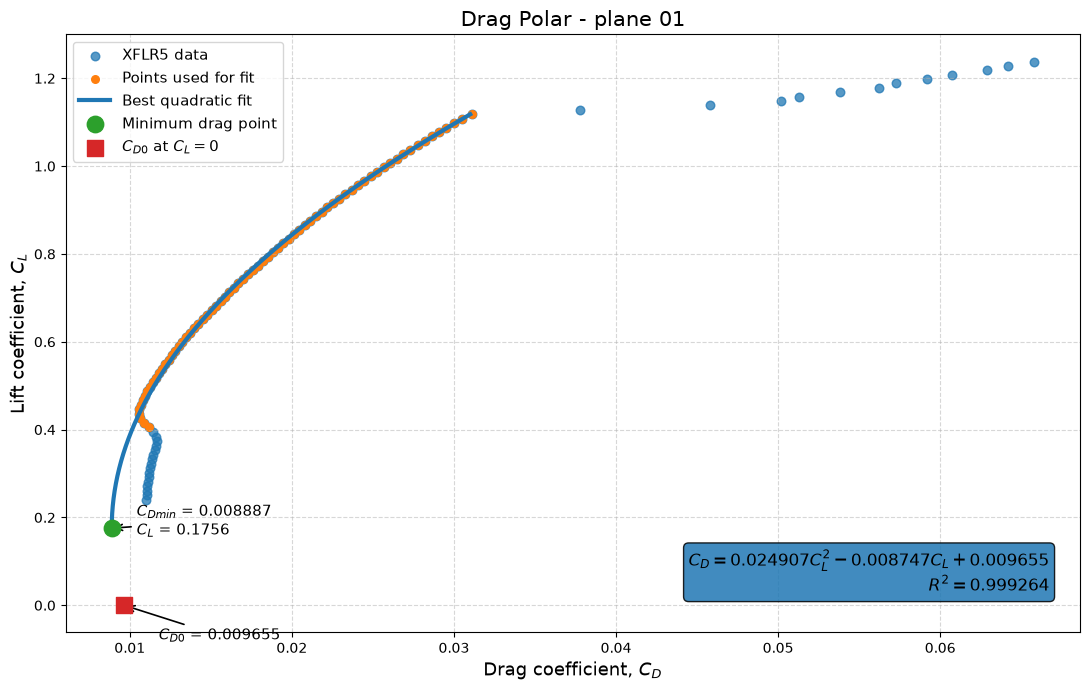

In [140]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


# ============================================================
# FILE LOCATION
# ============================================================

folder = r"C:\Users\Senura\Desktop\Aircraft design project\Xflr analysis\plane"

filename = "plane 01.txt"      # Change only this line

file_path = f"{folder}\\{filename}"


# ============================================================
# FITTING RANGE
# ============================================================
# Select the approximately parabolic, pre-stall region.
# Change these values according to your polar.

CL_fit_min = 0.40
CL_fit_max = 1.12


# ============================================================
# READ XFLR5 PLANE POLAR
# ============================================================

CL_data = []
CD_data = []

with open(file_path, "r", errors="ignore") as file:

    for line in file:

        parts = line.split()

        try:
            values = [float(value) for value in parts]

            # XFLR5 plane polar:
            # 0 = alpha
            # 1 = Beta
            # 2 = CL
            # 3 = CDi
            # 4 = CDv
            # 5 = total CD

            if len(values) >= 6:

                CL = values[2]
                CD = values[5]

                if np.isfinite(CL) and np.isfinite(CD) and CD > 0:
                    CL_data.append(CL)
                    CD_data.append(CD)

        except ValueError:
            continue


CL_data = np.asarray(CL_data, dtype=float)
CD_data = np.asarray(CD_data, dtype=float)

if len(CL_data) < 3:
    raise ValueError("Not enough valid CL-CD data points were found.")


# ============================================================
# SELECT POINTS FOR QUADRATIC FIT
# ============================================================

fit_mask = (
    (CL_data >= CL_fit_min)
    & (CL_data <= CL_fit_max)
)

CL_fit_data = CL_data[fit_mask]
CD_fit_data = CD_data[fit_mask]

if len(CL_fit_data) < 3:
    raise ValueError(
        "The selected CL fitting range has fewer than three points."
    )


# ============================================================
# QUADRATIC FIT
#
# CD = a(CL)^2 + b(CL) + c
# ============================================================

a, b, c = np.polyfit(CL_fit_data, CD_fit_data, 2)

if a <= 0:
    raise ValueError(
        "The fitted curve does not open toward increasing CD. "
        "Change the CL fitting range."
    )


# ============================================================
# CALCULATE IMPORTANT VALUES
# ============================================================

# Drag at CL = 0
CD0_w = c

# Vertex of the quadratic curve
CL_at_CDmin = -b / (2.0 * a)

CDmin = (
    a * CL_at_CDmin**2
    + b * CL_at_CDmin
    + c
)


# ============================================================
# R-SQUARED
# ============================================================

CD_predicted = (
    a * CL_fit_data**2
    + b * CL_fit_data
    + c
)

SS_res = np.sum((CD_fit_data - CD_predicted)**2)
SS_tot = np.sum((CD_fit_data - np.mean(CD_fit_data))**2)

R_squared = 1.0 - SS_res / SS_tot


# ============================================================
# PRINT RESULTS
# ============================================================

print("\n" + "=" * 65)
print("QUADRATIC DRAG POLAR")
print("=" * 65)

print(f"File                    : {Path(file_path).name}")
print(f"Number of fitted points : {len(CL_fit_data)}")

print(
    f"\nCD = {a:.8f} CL² "
    f"{b:+.8f} CL "
    f"{c:+.8f}"
)

print(f"\nCDmin        = {CDmin:.8f}")
print(f"CD0          = {CD0_w:.8f}")
print(f"CL at CDmin  = {CL_at_CDmin:.8f}")
print(f"R²           = {R_squared:.8f}")


# ============================================================
# SMOOTH PHYSICAL DRAG-POLAR CURVE
# ============================================================
# Start at the minimum-drag point.
# This prevents the unwanted lower branch of the parabola.

CL_curve_start = CL_at_CDmin
CL_curve_end = np.max(CL_fit_data)

CL_curve = np.linspace(
    CL_curve_start,
    CL_curve_end,
    500
)

CD_curve = (
    a * CL_curve**2
    + b * CL_curve
    + c
)


# ============================================================
# PLOT
# ============================================================

plt.figure(figsize=(11, 7))

# All XFLR5 data
plt.scatter(
    CD_data,
    CL_data,
    s=38,
    alpha=0.75,
    label="XFLR5 data"
)

# Points used in quadratic fit
plt.scatter(
    CD_fit_data,
    CL_fit_data,
    s=30,
    label="Points used for fit"
)

# Best physical quadratic branch
plt.plot(
    CD_curve,
    CL_curve,
    linewidth=3,
    label="Best quadratic fit"
)

# Minimum-drag point
plt.scatter(
    CDmin,
    CL_at_CDmin,
    s=140,
    marker="o",
    zorder=5,
    label="Minimum drag point"
)

# CD0 point
plt.scatter(
    CD0_w,
    0.0,
    s=130,
    marker="s",
    zorder=5,
    label=r"$C_{D0}$ at $C_L=0$"
)


# ============================================================
# ANNOTATIONS
# ============================================================

plt.annotate(
    f"$C_{{Dmin}}$ = {CDmin:.6f}\n"
    f"$C_L$ = {CL_at_CDmin:.4f}",
    xy=(CDmin, CL_at_CDmin),
    xytext=(18, -5),
    textcoords="offset points",
    arrowprops=dict(
        arrowstyle="->",
        linewidth=1.2
    ),
    fontsize=11
)

plt.annotate(
    f"$C_{{D0}}$ = {CD0_w:.6f}",
    xy=(CD0_w, 0.0),
    xytext=(25, -25),
    textcoords="offset points",
    arrowprops=dict(
        arrowstyle="->",
        linewidth=1.2
    ),
    fontsize=11
)

equation_text = (
    r"$C_D = "
    f"{a:.6f}C_L^2"
    f"{b:+.6f}C_L"
    f"{c:+.6f}$"
    "\n"
    rf"$R^2 = {R_squared:.6f}$"
)

plt.text(
    0.97,
    0.06,
    equation_text,
    transform=plt.gca().transAxes,
    horizontalalignment="right",
    verticalalignment="bottom",
    fontsize=12,
    bbox=dict(
        boxstyle="round",
        alpha=0.85
    )
)


# ============================================================
# GRAPH FORMAT
# ============================================================

plt.xlabel(
    r"Drag coefficient, $C_D$",
    fontsize=13
)

plt.ylabel(
    r"Lift coefficient, $C_L$",
    fontsize=13
)

plt.title(
    f"Drag Polar - {Path(filename).stem}",
    fontsize=15
)

plt.grid(
    True,
    linestyle="--",
    alpha=0.5
)

plt.legend(
    loc="best",
    fontsize=11
)

plt.tight_layout()
plt.show()

Aircraft CD0 = 0.013500


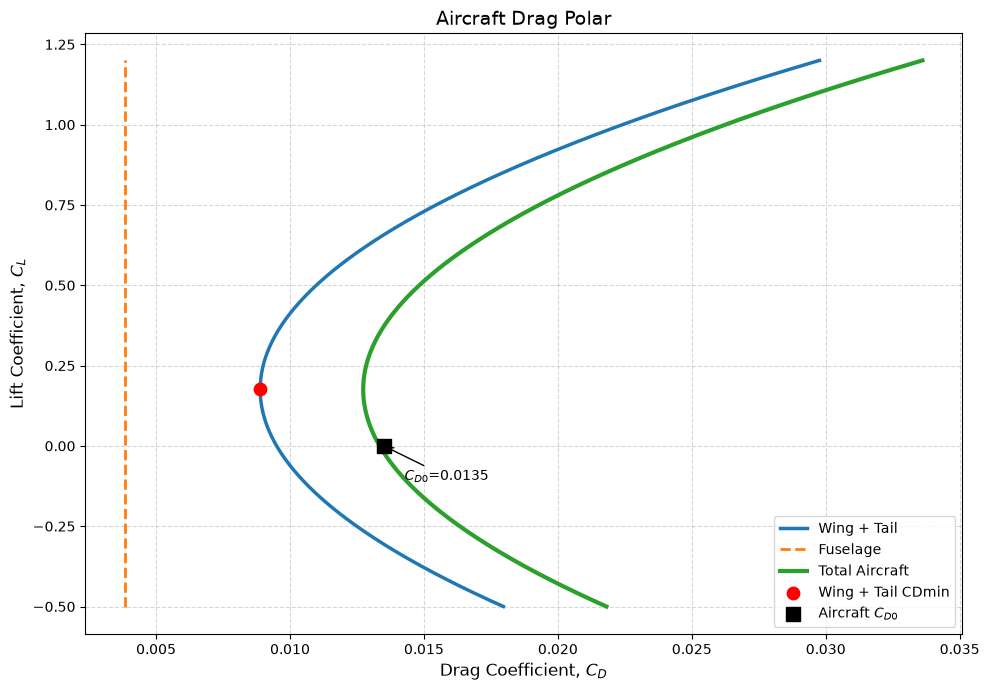

0.0135


In [144]:

CL = np.linspace(-0.5, 1.2, 400)

# -------------------------------
# Wing + Tail Drag Polar
# -------------------------------
CD_min = CDmin
CL_min = CL_at_CDmin

CD_wt = CD_min + k * (CL - CL_min)**2

# -------------------------------
# Fuselage Drag
# -------------------------------
CD_f = np.full_like(CL, CD0-CD0_w)     # <-- Use your actual fuselage CD0

# -------------------------------
# Total Aircraft Drag
# -------------------------------
CD_aircraft = CD_wt + CD_f

# -------------------------------
# Aircraft CD0
# -------------------------------
CD0_aircraft = CD0_w + CD_f[0]

print(f"Aircraft CD0 = {CD0_aircraft:.6f}")

plt.figure(figsize=(10,7))

# Wing + Tail
plt.plot(
    CD_wt,
    CL,
    linewidth=2.5,
    label='Wing + Tail'
)

# Fuselage
plt.plot(
    CD_f,
    CL,
    '--',
    linewidth=2,
    label='Fuselage'
)

# Aircraft
plt.plot(
    CD_aircraft,
    CL,
    linewidth=3,
    label='Total Aircraft'
)

# Minimum drag point
plt.scatter(
    CD_min,
    CL_min,
    color='red',
    s=80,
    zorder=5,
    label='Wing + Tail CDmin'
)

plt.scatter(
    CD0_aircraft,
    0,
    color='black',
    marker='s',
    s=90,
    zorder=5,
    label='Aircraft $C_{D0}$'
)

plt.annotate(
    f"$C_{{D0}}$={CD0_aircraft:.4f}",
    xy=(CD0_aircraft,0),
    xytext=(15,-25),
    textcoords='offset points',
    arrowprops=dict(arrowstyle='->')
)

plt.xlabel(r"Drag Coefficient, $C_D$", fontsize=12)
plt.ylabel(r"Lift Coefficient, $C_L$", fontsize=12)
plt.title("Aircraft Drag Polar", fontsize=14)

plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()


print(CD0)

Total aircraft CD0         = 0.013345
Total aircraft CDmin       = 0.012732
CL at aircraft CDmin       = 0.175588


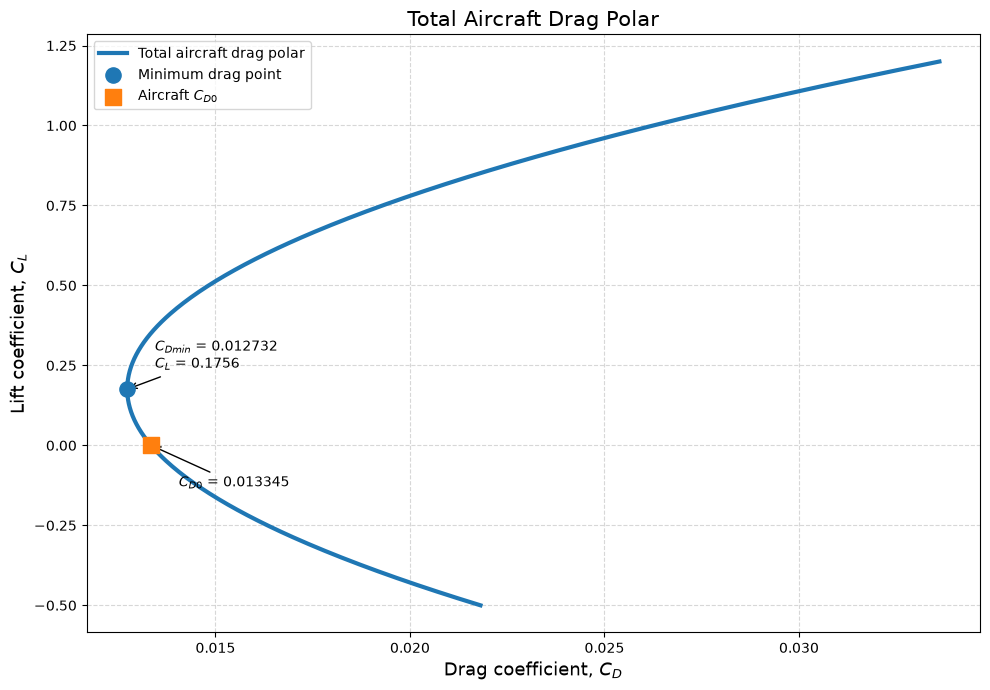

In [145]:
import numpy as np
import matplotlib.pyplot as plt

CL = np.linspace(-0.5, 1.2, 400)

# Wing + tail drag polar
CD_min = CDmin
CL_min = CL_at_CDmin

CD_wt = CD_min + k * (CL - CL_min)**2

# Fuselage drag coefficient
CD_f = CD0 - CD0_w

# Total aircraft drag polar
CD_aircraft = CD_wt + CD_f

# Total aircraft CD0 at CL = 0
CD0_aircraft = (
    CD_min
    + k * (0.0 - CL_min)**2
    + CD_f
)

# Total aircraft minimum drag
CDmin_aircraft = CD_min + CD_f

print(f"Total aircraft CD0         = {CD0_aircraft:.6f}")
print(f"Total aircraft CDmin       = {CDmin_aircraft:.6f}")
print(f"CL at aircraft CDmin       = {CL_min:.6f}")


# ============================================================
# PLOT TOTAL AIRCRAFT DRAG POLAR ONLY
# ============================================================

plt.figure(figsize=(10, 7))

plt.plot(
    CD_aircraft,
    CL,
    linewidth=3,
    label="Total aircraft drag polar"
)

# Aircraft minimum-drag point
plt.scatter(
    CDmin_aircraft,
    CL_min,
    s=120,
    zorder=5,
    label="Minimum drag point"
)

# Aircraft CD0 point
plt.scatter(
    CD0_aircraft,
    0.0,
    marker="s",
    s=120,
    zorder=5,
    label=r"Aircraft $C_{D0}$"
)

plt.annotate(
    f"$C_{{Dmin}}$ = {CDmin_aircraft:.6f}\n"
    f"$C_L$ = {CL_min:.4f}",
    xy=(CDmin_aircraft, CL_min),
    xytext=(20, 15),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->")
)

plt.annotate(
    f"$C_{{D0}}$ = {CD0_aircraft:.6f}",
    xy=(CD0_aircraft, 0.0),
    xytext=(20, -30),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->")
)

plt.xlabel(r"Drag coefficient, $C_D$", fontsize=13)
plt.ylabel(r"Lift coefficient, $C_L$", fontsize=13)
plt.title("Total Aircraft Drag Polar", fontsize=15)

plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()